In [7]:
from torchvision import transforms
import get_data
import coatnet
from torch import nn
from torch import optim
from torch.optim import lr_scheduler
import train


# Define image augmentation for training data
train_transforms = transforms.Compose([
    transforms.Resize(224), 
    transforms.RandAugment(2, 20),
    transforms.ToTensor()
])
image_transforms = {
    "train": train_transforms,
    "val": None,
    "test": None
}

# Load the data
splits = get_data.generate_train_val_test_splits(debug=False)
data_loaders = get_data.load_data(splits, image_transforms=image_transforms)

# Define model
args = {
    "image_size": (224, 224),
    "in_channels": 3,
    "num_blocks": [2, 2, 3, 5, 2],
    "channels": [64, 96, 192, 384, 768],
    "num_classes": 10,
    "block_types": ["C", "C", "C", "T"]
}
model = coatnet.CoAtNet(
    image_size=args["image_size"],
    in_channels=args["in_channels"],
    num_blocks=args["num_blocks"],
    channels=args["channels"],
    num_classes=args["num_classes"],
    block_types=args["block_types"]
)

# Define optimizer, scheduler and loss
max_epochs = 100 # total number of epochs to train the model
n_epochs = 2 # number of epochs to train the model in this cycle
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-5)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train model
history = train.train(
    model=model, 
    data_loaders=data_loaders, 
    n_epochs=n_epochs,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler
)

C:\Users\nikhi\.astroNN\datasets\Galaxy10_DECals.h5 was found!
Epoch [1/2]: Train Loss = 2.2220; Train Acc. = 0.2750
Epoch [1/2]: Val Loss = 1.7215; Val Acc. = 0.4055

Epoch [2/2]: Train Loss = 1.7901; Train Acc. = 0.4026
Epoch [2/2]: Val Loss = 1.7196; Val Acc. = 0.4320



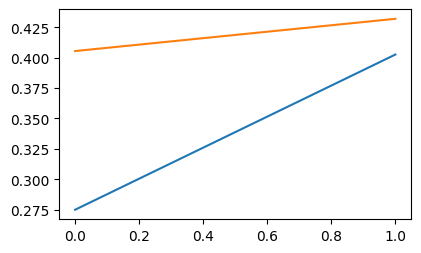

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot([i.item() for i in history["train_accuracy"]])
plt.plot([i.item() for i in history["val_accuracy"]])

plt.show()

In [11]:
history["train_accuracy"]

[tensor(0.2750, device='cuda:0'), tensor(0.4026, device='cuda:0')]

In [ ]:
import torch


# Save model state dict
PATH = "saved_models/coatnet.new.1.pt"
torch.save(
    {
        "model_state": model.state_dict(),
        "model_args": args,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "epoch": n_epochs
    }, 
    PATH
)

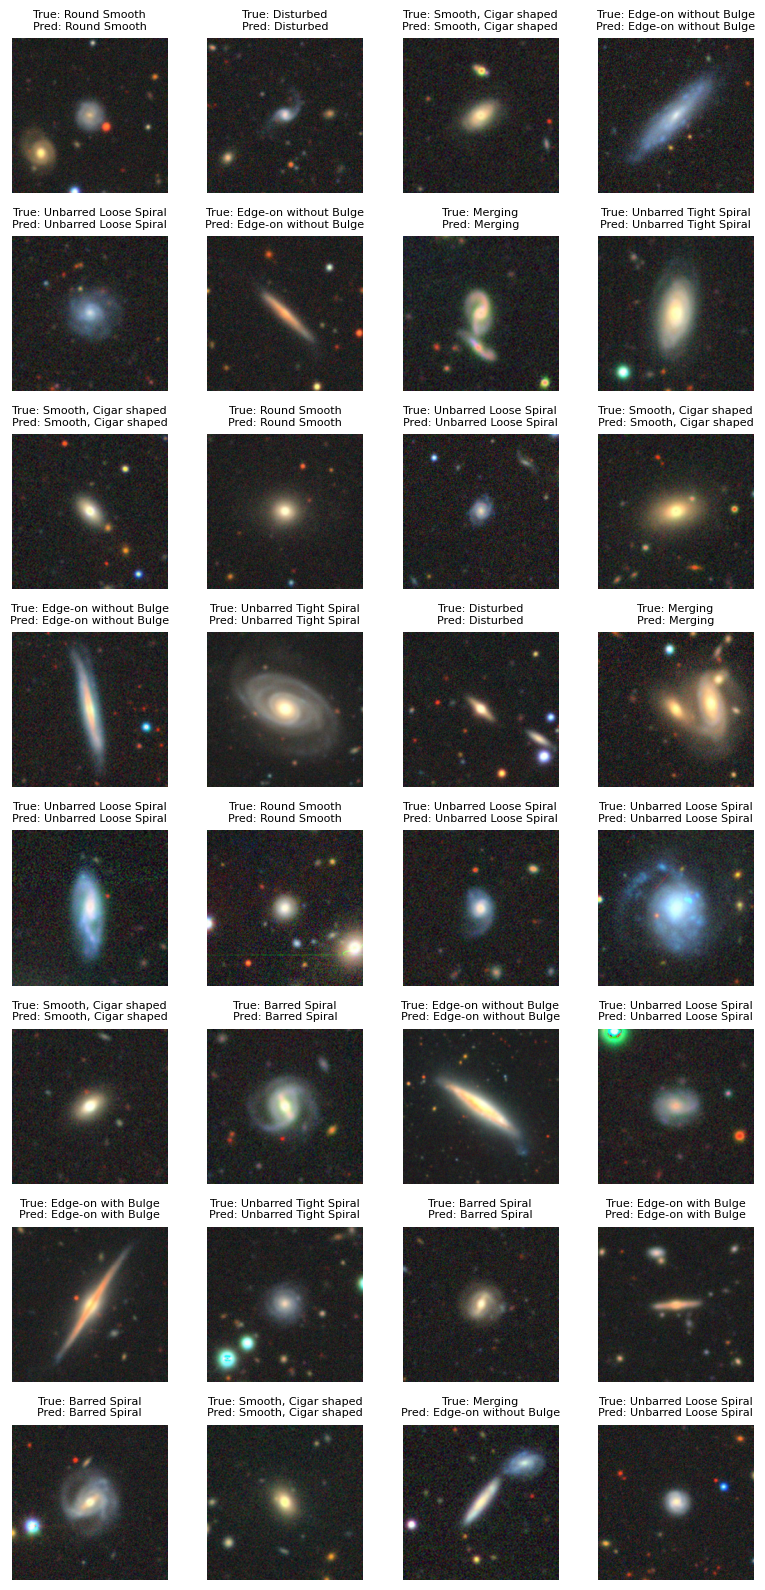

In [40]:
import understand


understand.inspect_predictions(model=model, data_loader=data_loaders["val"], batches=2)

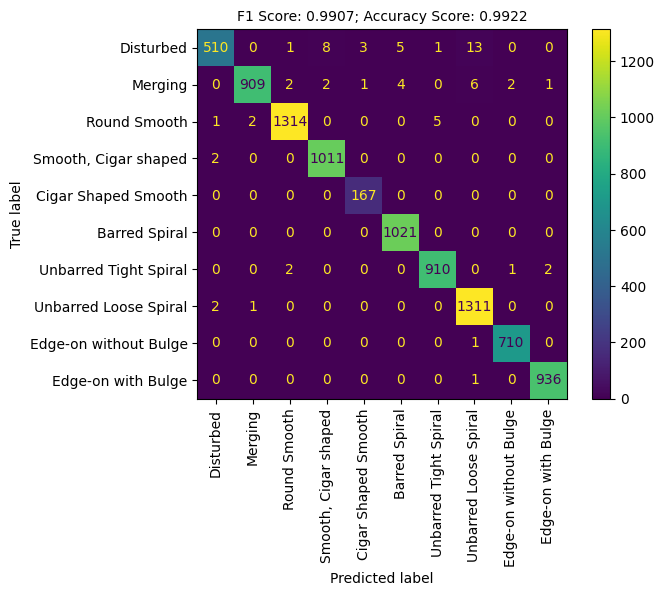

In [68]:
import train
from sklearn import metrics
import matplotlib.pyplot as plt
from astroNN.datasets import galaxy10


# y_hat, y = train.predict(model, data_loaders["val"])
f1_score = metrics.f1_score(y, y_hat, average="macro")
accuracy_score = metrics.accuracy_score(y, y_hat)

# Display confusion matrix
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=y_hat,
    display_labels=[galaxy10.galaxy10cls_lookup(i) for i in range(10)],
    xticks_rotation="vertical"
)
plt.title(f"F1 Score: {f1_score:.04f}; Accuracy Score: {accuracy_score:.04f}", fontsize=10)
plt.show()